In [ ]:
%pip install langgraph

In [2]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [ ]:
class State(TypedDict):
    '''
    Messages have the type list[dict]
    'add_messages' is a decorator that adds the messages to the state.
    '''
    messages : Annotated[list[dict], add_messages]
    

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
%pip install langchain_google_genai

Note: you may need to restart the kernel to use updated packages.


In [16]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
llm

ChatGoogleGenerativeAI(model='models/gemini-2.5-flash', google_api_key=SecretStr('**********'), temperature=0.0, client=<google.ai.generativelanguage_v1beta.services.generative_service.client.GenerativeServiceClient object at 0x74e6002402b0>, default_metadata=(), model_kwargs={})

In [17]:
def chatbot(state: State) -> State:
    """
    Chatbot function that processes messages and generates responses.
    Fixed to properly handle LLM string responses.
    """
    # Get response from LLM (returns string)
    response = llm.invoke(state["messages"])
    
    # Convert string response to AIMessage object
    from langchain_core.messages import AIMessage
    ai_message = AIMessage(content=response)
    
    # Return only the new message - add_messages will handle the merging
    return {"messages": [ai_message]}

In [18]:
# Build and compile the graph
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

# Compile the graph
graph = graph_builder.compile()
print("✅ Chatbot graph compiled successfully!")

✅ Chatbot graph compiled successfully!


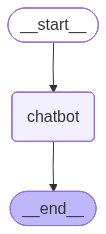

In [9]:
from IPython.display import display, Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass
    

In [10]:
result = graph.invoke({"messages": [{"role": "user", "content": "Hello!"}]})
print(result["messages"])  # Last message content

[HumanMessage(content='Hello!', additional_kwargs={}, response_metadata={}, id='eee8a034-0670-499a-8fd8-e9a638a4189f'), AIMessage(content='Hello there! How can I help you today?', additional_kwargs={}, response_metadata={}, id='4a16259f-e5d9-4883-a030-fb16f12266ca')]


## Chatbot with Tools

In [ ]:
%pip install langchain-tavily

In [ ]:
from langchain_tavily import TavilySearch
# Create a custom Tavily wrapper that works with Gemini
from langchain_core.tools import tool

# Initialize the Tavily client
tavily_client = TavilySearch(max_results=2)

@tool
def search_web(query: str) -> str:
    """
    Search the web using Tavily for current information.
    
    Args:
        query (str): The search query to look up information about
        
    Returns:
        str: Search results with relevant information
    """
    try:
        results = tavily_client.invoke(query)
        if isinstance(results, list) and len(results) > 0:
            # Format the results nicely
            formatted_results = []
            for i, result in enumerate(results[:2], 1):
                if isinstance(result, dict):
                    title = result.get('title', 'No title')
                    content = result.get('content', 'No content')
                    url = result.get('url', 'No URL')
                    formatted_results.append(f"{i}. {title}\n   {content[:200]}...\n   Source: {url}")
                else:
                    formatted_results.append(f"{i}. {str(result)[:200]}...")
            return "\n\n".join(formatted_results)
        else:
            return f"Search results for '{query}': {str(results)[:500]}"
    except Exception as e:
        return f"Search failed: {str(e)}"

# Test the custom search tool
test_result = search_web("What is LangGraph")
print("Custom search tool test:")
print(test_result[:300] + "...")
print("✅ Custom Tavily wrapper created successfully!")

Custom search tool test:
Search results for 'What is LangGraph': {'query': 'What is LangGraph', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.datacamp.com/tutorial/langgraph-tutorial', 'title': 'LangGraph Tutorial: What Is LangGraph and How to Use It?', 'content': 'LangGraph is ...
✅ Custom Tavily wrapper created successfully!


In [43]:
from langchain_core.tools import tool

@tool
def multiply(a : int, b : int) -> int:
    """
    Multiply a and b
    
    Args:
        a (int) : first int
        b (int) : second int
        
    Returns:
        int : output int
    """
    
    return a * b

In [ ]:
# Now we can use both tools!
tools = [multiply, search_web]
print(f"Available tools: {[t.name for t in tools]}")

# Test binding with both tools
try:
    llm_with_tools = llm.bind_tools(tools)
    print("Both tools bound successfully!")
    print("Tavily search is now working with Gemini!")
except Exception as e:
    print(f"Tool binding failed: {e}")

Available tools: ['multiply', 'search_web']
✅ Both tools bound successfully!
✅ Tavily search is now working with Gemini!


In [81]:
# Build complete chatbot with both math and search capabilities
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

def tool_calling_llm(state: State) -> State:
    """LLM that can call both math and search tools"""
    response = llm_with_tools.invoke(state["messages"])
    
    # response is already an AIMessage object (not a string like in basic chatbot)
    # So we don't need to wrap it in AIMessage() again
    return {"messages": [response]}

# Build the graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)

# Compile
complete_tool_graph = builder.compile(checkpointer=memory)

# Quick test
# from langchain_core.messages import HumanMessage

# print("\n=== Quick Tests ===")

# # Test math
# math_result = complete_tool_graph.invoke({"messages": [HumanMessage(content="What is 12 times 34?")]})
# print(f"Math test: {math_result['messages'][-1].content}")

# # Test search  
# search_result = complete_tool_graph.invoke({"messages": [HumanMessage(content="What is Python programming language?")]})
# print(f"Search test: {search_result['messages'][-1].content[:100]}...")


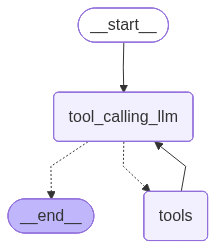

In [82]:
from IPython.display import display, Image
try:
    display(Image(complete_tool_graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [74]:
config = {"configurable":{"thread_id": "1"}}
response = complete_tool_graph.invoke({"messages": [HumanMessage(content="Hi my name is Amar")]}, config=config)

In [75]:
response['messages'][-1].content

'Hello Amar, nice to meet you! How can I help you today?'

In [77]:
response = complete_tool_graph.invoke({"messages": [HumanMessage(content="What is my name?")]}, config=config)
response['messages'][-1].content

'Your name is Amar.'

In [83]:
response = complete_tool_graph.invoke({"messages": [HumanMessage(content="What is recent F1 news and 12 times 34?")]}, config=config)

In [84]:
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

What is recent F1 news and 12 times 34?
================================== Ai Message ==================================
Tool Calls:
  search_web (65ba5dae-38a1-4ff4-bb36-c0ab85f7a148)
 Call ID: 65ba5dae-38a1-4ff4-bb36-c0ab85f7a148
  Args:
    query: recent F1 news
  multiply (82d48643-f512-441d-98af-0328075b0deb)
 Call ID: 82d48643-f512-441d-98af-0328075b0deb
  Args:
    a: 12.0
    b: 34.0
================================= Tool Message =================================
Name: search_web

Search results for 'recent F1 news': {'query': 'recent F1 news', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.newsnow.com/us/Sports/F1', 'title': 'F1 - Latest Formula One News - NewsNow', 'content': 'Latest F1 news in a live feed, including breaking news, race results, driver interviews, analysis, commentary and all updates relating to Formula 1 racing.', 'score': 0.783542, 

## Streaming

In [95]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [99]:
def streambot(state: State) -> State:
    """
    Chatbot function that processes messages and generates responses in a streaming manner.
    """
    # Get response from LLM (returns string)
    response = llm.invoke(state["messages"], streaming=True)
    
    # # Convert string response to AIMessage object
    # from langchain_core.messages import AIMessage
    # ai_message = AIMessage(content=response)
    
    # Return only the new message - add_messages will handle the merging
    return {"messages": [response]}

In [100]:
graph = StateGraph(State)

graph.add_node("streambot", streambot)
graph.add_edge(START, "streambot")
graph.add_edge("streambot", END)

builder = graph.compile(checkpointer=memory)

# display = Image(builder.get_graph().draw_mermaid_png())

In [101]:
config = {"configurable":{"thread_id": "2"}}

response = builder.invoke({"messages": [HumanMessage(content="Hi my name is Amar and I like football")]}, config=config)

In [103]:
for chunk in builder.stream({"messages": [HumanMessage(content="Hi my name is Amar and I like football")]}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi my name is Amar and I like football', additional_kwargs={}, response_metadata={}, id='abb606f4-1d52-4124-9f09-5ef4b2c2381e'), HumanMessage(content='Hi my name is Amar and I like football', additional_kwargs={}, response_metadata={}, id='9a7f982c-effb-45ec-a574-7be0ec9d999a'), AIMessage(content="Hi Amar! It's great to meet you. Football is a fantastic sport! Do you have a favorite team or player?", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--b29e6a2c-d0b6-4106-84bf-7a8adca21b6d-0', usage_metadata={'input_tokens': 20, 'output_tokens': 59, 'total_tokens': 79, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 33}}), HumanMessage(content='Hi my name is Amar and I like football', additional_kwargs={}, response_metadata={}, id='1e0a4b4a-ae4f-4df0-bd3a-ae41c03efa1f'), AIMessage(